In [1]:
%load_ext autoreload
%autoreload 2

import sys
print(sys.executable)

from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses
print("imports OK")

C:\Users\Antonio\Desktop\TSE\ZZ OTHER\Market Risk Engine\market-risk-engine\.venv\Scripts\python.exe
imports OK


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses

TICKERS = ["SAN.MC", "BBVA.MC", "IBE.MC", "ITX.MC", "TEF.MC", "REP.MC"]
prices = load_prices(TICKERS, start="2015-01-01", end="2026-06-30")

rets = simple_returns(prices)
w = np.full(len(TICKERS), 1 / len(TICKERS))
loss = portfolio_losses(rets, w)

In [4]:
print(prices.shape)
print(prices.tail())

(2938, 6)
Ticker        BBVA.MC     IBE.MC     ITX.MC     REP.MC  SAN.MC  TEF.MC
Date                                                                  
2026-06-23  21.690001  20.764381  55.160000  21.271832  11.930   3.690
2026-06-24  21.320000  20.734970  55.779999  20.501326  11.862   3.679
2026-06-25  21.690001  21.038887  56.520000  20.910961  11.916   3.675
2026-06-26  21.469999  21.264374  56.000000  20.715897  11.830   3.651
2026-06-29  21.549999  21.391823  55.400002  21.037754  11.918   3.590


skewness:  0.5140121172433605
excess kurtosis: 14.78091364119183
SignificanceResult(statistic=np.float64(26865.258101908305), pvalue=np.float64(0.0))


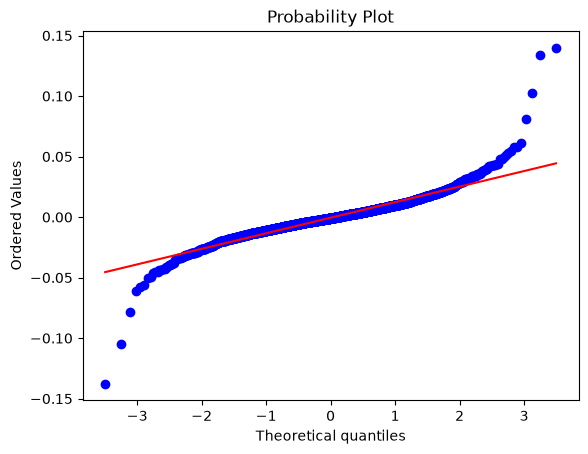

In [5]:
# Stylised fact 1: heavy tails
print("skewness: ", stats.skew(loss))
print("excess kurtosis:", stats.kurtosis(loss)) # 0 under normality
print(stats.jarque_bera(loss)) # H0: normal

stats.probplot(loss, dist="norm", plot=plt) # QQ plot vs normal
plt.show()

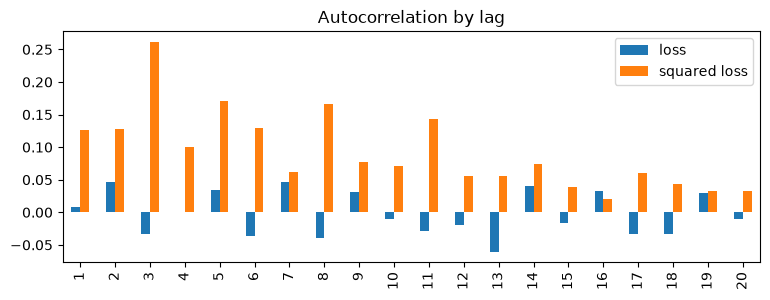

In [6]:
# Stylised fact 2: volatility clustering
lags = range(1, 21)
acf = pd.DataFrame({
"loss": [loss.autocorr(k) for k in lags],
"squared loss": [(loss**2).autocorr(k) for k in lags],
}, index=lags)
acf.plot.bar(figsize=(9, 3), title="Autocorrelation by lag")
plt.show()